In [ ]:
!pip -q install numpy pandas scipy matplotlib scikit-learn torch

import os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================
# 1) Load ECG signals X (mmap)
# ================================
BASE = "/content/drive/MyDrive/Colab Notebooks"

X_path = f"{BASE}/X_ptbxl_500hz.npy"
X = np.load(X_path, mmap_mode="r")
print("X shape:", X.shape)  # expected (21799, 12, 5000)

X shape: (21799, 12, 5000)


In [ ]:
# ================================
# 2) Load PTB-XL metadata & Build Y for 6 labels
#    classes = ["NORM","IMI","ASMI","LVH","NDT","LAFB"]
# ================================
df = pd.read_csv(f"{BASE}/ptbxl_database.csv")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c: i for i, c in enumerate(classes)}

Y = np.zeros((len(df), len(classes)), dtype=np.float32)
for i, codes in enumerate(df["scp_codes"]):
    for c in classes:
        if c in codes:
            Y[i, class_to_idx[c]] = 1.0

print("Y shape:", Y.shape)
print("Counts:", dict(zip(classes, Y.sum(axis=0).astype(int))))

assert X.shape[0] == Y.shape[0]
np.save(f"{BASE}/Y_6labels.npy", Y)

Y shape: (21799, 6)
Counts: {'NORM': np.int64(9514), 'IMI': np.int64(2676), 'ASMI': np.int64(2357), 'LVH': np.int64(2132), 'NDT': np.int64(1825), 'LAFB': np.int64(1623)}


In [ ]:
# ================================
# 3) Signal preprocessing + STFT
# ================================
def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    specs = []
    for lead in range(ecg_time_leads.shape[1]):  # 12
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len-hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )
        mag = np.abs(Z)
        keep = f <= fmax
        mag = mag[keep, :]

        # log scale + normalize
        mag = np.log1p(mag)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)

        specs.append(mag.astype(np.float32))
    return np.stack(specs, axis=0)  # (12, F, T)

# Quick sanity: one sample spectrogram shape
ecg0 = X[0].T  # (5000, 12)
ecg0 = bandpass_filter(ecg0, fs=500)
ecg0 = (ecg0 - ecg0.mean(axis=0)) / (ecg0.std(axis=0) + 1e-8)
spec0 = ecg_to_spectrogram_tensor(ecg0, fs=500)
print("One spec shape:", spec0.shape)  # expected (12, 41, 38)

One spec shape: (12, 41, 38)


In [ ]:
# ================================
# 4) PyTorch Dataset (STFT on-the-fly)
# ================================
class PTBXLSpectrogramDataset(Dataset):
    def __init__(self, X_mmap, Y, fs=500):
        self.X = X_mmap
        self.Y = Y
        self.fs = fs

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        ecg = self.X[idx].T  # (5000, 12)

        ecg = bandpass_filter(ecg, fs=self.fs, low=0.5, high=40.0)
        ecg = (ecg - ecg.mean(axis=0)) / (ecg.std(axis=0) + 1e-8)

        spec = ecg_to_spectrogram_tensor(ecg, fs=self.fs)  # (12, 41, 38)

        x = torch.from_numpy(spec)                 # float32
        y = torch.from_numpy(self.Y[idx]).float()  # (6,)
        return x, y

In [ ]:
# ================================
# 5) Train/Val split + DataLoaders
# ================================
idx_all = np.arange(X.shape[0])
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=42)

train_ds = torch.utils.data.Subset(PTBXLSpectrogramDataset(X, Y), train_idx)
val_ds   = torch.utils.data.Subset(PTBXLSpectrogramDataset(X, Y), val_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# ================================
# 6) Deeper CNN Model
# ================================
class DeeperSpecCNN(nn.Module):
    def __init__(self, n_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(12, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = DeeperSpecCNN(n_classes=len(classes)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using device:", device)

Using device: cuda


In [ ]:
# ================================
# 7) Training loop
# ================================
def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0

    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

EPOCHS = 8
for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch(model, train_loader, training=True)
    va_loss = run_epoch(model, val_loader, training=False)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}")


Epoch 1: train_loss=0.2815  val_loss=0.4731
Epoch 2: train_loss=0.2513  val_loss=0.2688
Epoch 3: train_loss=0.2413  val_loss=0.2421
Epoch 4: train_loss=0.2342  val_loss=0.2376
Epoch 5: train_loss=0.2282  val_loss=0.2252
Epoch 6: train_loss=0.2215  val_loss=0.2245
Epoch 7: train_loss=0.2170  val_loss=0.2273
Epoch 8: train_loss=0.2124  val_loss=0.2211


In [ ]:
# ================================
# 8) Evaluate: AUROC + Precision/Recall/F1 (0.5 threshold)
# ================================
def get_outputs(model, loader):
    model.eval()
    all_true, all_prob = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            prob = torch.sigmoid(model(xb)).cpu().numpy()
            all_prob.append(prob)
            all_true.append(yb.numpy())
    return np.vstack(all_true), np.vstack(all_prob)

y_true, y_prob = get_outputs(model, val_loader)
y_pred = (y_prob >= 0.5).astype(int)

print("\nAUROC per class:")
aucs = []
for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        print(f"{name}: AUROC not defined")
        continue
    auc_k = roc_auc_score(y_true[:, k], y_prob[:, k])
    aucs.append(auc_k)
    print(f"{name}: {auc_k:.4f}")
print("Macro AUROC:", float(np.mean(aucs)) if aucs else None)

print("\nMacro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))



AUROC per class:
NORM: 0.9282
IMI: 0.8699
ASMI: 0.9329
LVH: 0.8620
NDT: 0.8791
LAFB: 0.9802
Macro AUROC: 0.9087338071399945

Macro Precision: 0.6820448493999584
Macro Recall   : 0.4404124048081306
Macro F1       : 0.5075352675356071
Micro Precision: 0.7518796992481203
Micro Recall   : 0.6228201295465869
Micro F1       : 0.6812917291184085


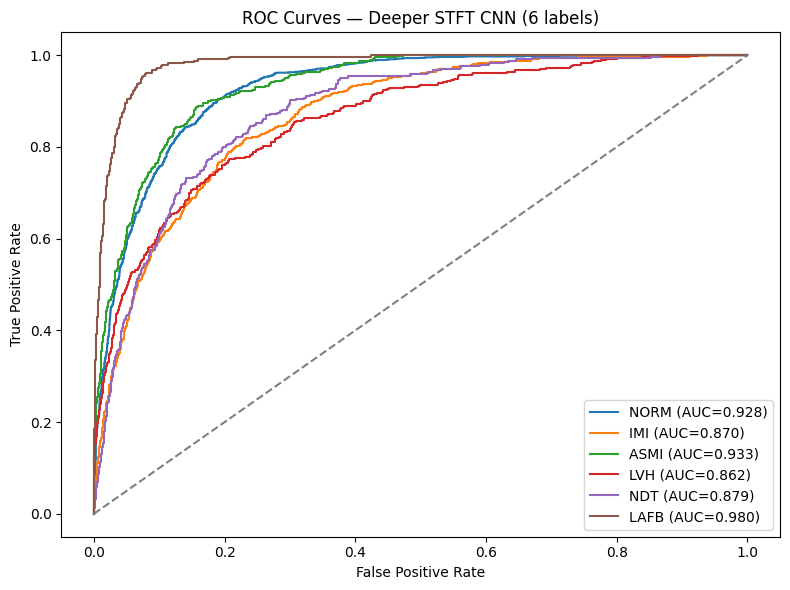

In [ ]:
# ================================
# 9) Plot ROC curves and save (optional, recommended)
# ================================
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for k, name in enumerate(classes):
    if len(np.unique(y_true[:, k])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true[:, k], y_prob[:, k])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Deeper STFT CNN (6 labels)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_deeper_stft_cnn.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Threshold = 0.5 (same as before)
y_pred = (y_prob >= 0.5).astype(int)

print("Per-Class Metrics (Deeper CNN)\n")

for k, name in enumerate(classes):
    precision = precision_score(y_true[:, k], y_pred[:, k], zero_division=0)
    recall    = recall_score(y_true[:, k], y_pred[:, k], zero_division=0)
    f1        = f1_score(y_true[:, k], y_pred[:, k], zero_division=0)
    acc       = accuracy_score(y_true[:, k], y_pred[:, k])

    print(f"{name}:")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print(f"  Accuracy  = {acc:.4f}")
    print("-" * 40)

Per-Class Metrics (Deeper CNN)

NORM:
  Precision = 0.7831
  Recall    = 0.9158
  F1-score  = 0.8443
  Accuracy  = 0.8491
----------------------------------------
IMI:
  Precision = 0.6063
  Recall    = 0.2967
  F1-score  = 0.3984
  Accuracy  = 0.8933
----------------------------------------
ASMI:
  Precision = 0.6942
  Recall    = 0.4680
  F1-score  = 0.5591
  Accuracy  = 0.9179
----------------------------------------
LVH:
  Precision = 0.7165
  Recall    = 0.2321
  F1-score  = 0.3507
  Accuracy  = 0.9227
----------------------------------------
NDT:
  Precision = 0.4889
  Recall    = 0.1310
  F1-score  = 0.2066
  Accuracy  = 0.9225
----------------------------------------
LAFB:
  Precision = 0.8032
  Recall    = 0.5988
  F1-score  = 0.6861
  Accuracy  = 0.9580
----------------------------------------


In [ ]:
print("\nOverall Metrics (Deeper CNN)\n")

print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))


Overall Metrics (Deeper CNN)

Macro Precision: 0.6820448493999584
Macro Recall   : 0.4404124048081306
Macro F1       : 0.5075352675356071
Micro Precision: 0.7518796992481203
Micro Recall   : 0.6228201295465869
Micro F1       : 0.6812917291184085


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

per_class_acc = []

for k, name in enumerate(classes):
    acc = accuracy_score(y_true[:, k], y_pred[:, k])
    per_class_acc.append(acc)
    print(f"{name}: Accuracy = {acc:.4f}")

macro_accuracy = np.mean(per_class_acc)
print("\nMacro Accuracy:", macro_accuracy)

NORM: Accuracy = 0.8491
IMI: Accuracy = 0.8933
ASMI: Accuracy = 0.9179
LVH: Accuracy = 0.9227
NDT: Accuracy = 0.9225
LAFB: Accuracy = 0.9580

Macro Accuracy: 0.9105886850152904
